# <span style="color:rgb(213,80,0)">Elektrikli Araç Şarj İstasyonu Kullanımı ve Şebeke Yükü Analizi</span>

Elektrikli araçlar sıfır egzoz emisyonuna sahip olsa da bu tamamen sıfır emisyona sahip oldukları anlamına gelmemekte. Bu, büyük bir yapıya sahip parçalardan sadece bir tanesi.

Örnek veri setinde ise elektrikli araçların şarj edilmesi konusu üzerine duruluyor. Aracın şarjı bittiği, azaldığı herhangi bir anda istasyona aracımızı brakma davranışında bulunuyoruz. Ancak bunun arkasındaki yapı tamamen 'elektrik kullanarak egzoz emisyonunu sıfıra indirdiriyor' gibi bir noktada değil.

Elektrik şebekeleri bir ağa benzetilebilir. Onlar da çökebilir, yavaşlayabilir. Var olan bu ağın da belirli bir sınırı, kaldırma kapasitesi vardır. Bunun için de istasyonlar peak saatlerde bir çöküntü, kesinti veya sorun yaşanmaması için fosil yakıt santralleri ile entegre bir şekilde çalışır.

\* Bu analizde ise gerçek sensör verilerine dayanmayan bir dataset yer alıyor.

## Set up the Import Options and import the data

Her şeyden önce dataset'i projeye import etmek gerekiyor.


In [1]:
opts = delimitedTextImportOptions("NumVariables", 10);


% Specify range and delimiter
opts.DataLines = [2, Inf];
opts.Delimiter = ",";


% Specify column names and types
opts.VariableNames = ["record_id", "date_time", "city_zone", "station_type", "vehicles_charged", "avg_charging_duration_minutes", "energy_dispensed_kwh", "grid_load_mw", "renewable_energy_used_percent", "peak_load_risk"];
opts.VariableTypes = ["double", "datetime", "categorical", "categorical", "double", "double", "double", "double", "double", "categorical"];


% Specify file level properties
opts.ExtraColumnsRule = "ignore";
opts.EmptyLineRule = "read";


% Specify variable properties
opts = setvaropts(opts, ["city_zone", "station_type", "peak_load_risk"], "EmptyFieldRule", "auto");
opts = setvaropts(opts, "date_time", "InputFormat", "yyyy-MM-dd HH:mm:ss", "DatetimeFormat", "preserveinput");


% Import the data
ev_charging_station_usage_grid_load = readtable("/MATLAB Drive/EV_archive/ev_charging_station_usage_grid_load.csv", opts)


## Clear temporary variables

In [2]:
%clear opts


Kullanım yoğunluğunu anlamak önceliğimiz. Bunun için de tarih ve saatleri kullanmamız gerekiyor. İlgili dataset içerisinde saat ve tarihler timestamp olarak yer alıyor. Analizde kullanabilmek ve grafikler oluşturabilmek için date\_time sütunu datetime formatında güncelleyeceğiz.


In [3]:
% date_time sütununun var olan türünü güncelliyoruz.
ev_charging_station_usage_grid_load.date_time=datetime(ev_charging_station_usage_grid_load.date_time, 'InputFormat', 'yyyy-MM-dd HH:mm:ss');
%Tarih ve saatler tek sütunda yer aldığı için her ikisini de farklı sütunlara kaydediyoruz.
ev_charging_station_usage_grid_load.date = datetime(ev_charging_station_usage_grid_load.date_time.Year, ev_charging_station_usage_grid_load.date_time.Month, ev_charging_station_usage_grid_load.date_time.Day,"Format","dd-MMM-uuuu");
ev_charging_station_usage_grid_load.time = timeofday(ev_charging_station_usage_grid_load.date_time);
ev_charging_station_usage_grid_load.timeofday = ev_charging_station_usage_grid_load.date_time.Hour;
ev_charging_station_usage_grid_load.day_name = day(ev_charging_station_usage_grid_load.date_time, "name");
head(ev_charging_station_usage_grid_load,5);

    record_id         date_time         city_zone    station_type    vehicles_charged    avg_charging_duration_minutes    energy_dispensed_kwh    grid_load_mw    renewable_energy_used_percent    peak_load_risk       date          time      timeofday     day_name 
    _________    ___________________    _________    ____________    ________________    _____________________________    ____________________    ____________    _____________________________    ______________    ___________    ________    _________    __________
        1        2024-01-01 00:00:00     Central     Supercharger            9                       101.6                       238.64              179.28                   59.1                     Medium        01-Jan-2024    00:00:00        0        {'Monday'}
        2        2024-01-01 01:00:00     South       Fast                   15                        23.5                        129.5              198.56                   73.6                     Low      


## Baseline Yük Eğrisi

Sensörlerden alınan verilere göre  01.01.2024\-26.04.2024 tarihleri arasındaki her saat başında ne kadar kWh enerji tüketildiğini grafik üzerinde göreceğiz.

Bu sayede hangi saatlerde istasyonlara yük bindiğini ve şebeke ile birlikte çalışıldığını göreceğiz.



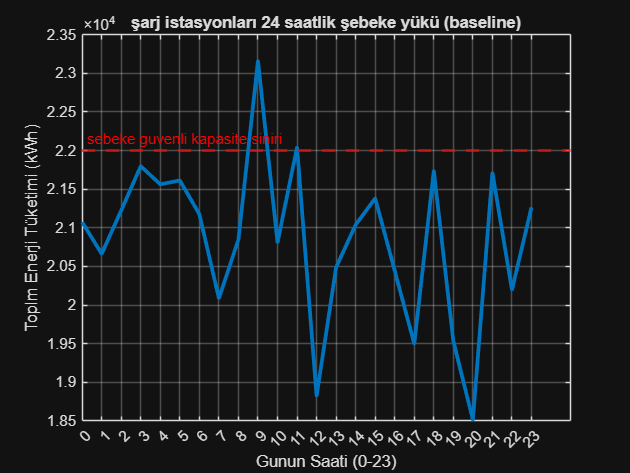

In [4]:
baseline_data=groupsummary(ev_charging_station_usage_grid_load,'timeofday','sum', 'energy_dispensed_kwh');
figure;
plot(baseline_data.timeofday,baseline_data.sum_energy_dispensed_kwh,'LineWidth',2.5,'Color',[0 0.45 0.74]);
grid on;


xlabel('Gunun Saati (0-23)');
ylabel('Toplm Enerji Tüketimi (kWh)');
title('şarj istasyonları 24 saatlik şebeke yükü (baseline)');


xticks(0:23);


% dataset'e bağlı olarak şebeke kapasite sınırını 22.000 kWh olarak kabul ettik.
sebeke_siniri = 22000;
yline(sebeke_siniri, '--r', 'sebeke guvenli kapasite siniri', 'LineWidth', 2, 'LabelHorizontalAlignment','left');


Grafikte gözlemlenen güvenlik kapasite sınırını aşan saat dilimlerinde şebekede aşırı yük oluşur ve sistemin çökmesini, yavaşlamasını önlemek için fosil yakıt şebekeleri ile birlikte çalışılır.

## Şebeke Yükü Dengelemesi

Grafikte peak noktalar dışında vadi noktaları da görünüyor. Şebeke üzerindeki baskıyı dengelemek ve fosil yakıt şebekelerine olan bağlılığı azaltabilmek için Peak noktaları kapasite sınırına kadar düşürelim ve düşürülen kısmı daha az yoğun olan saatlere dağıtalım.



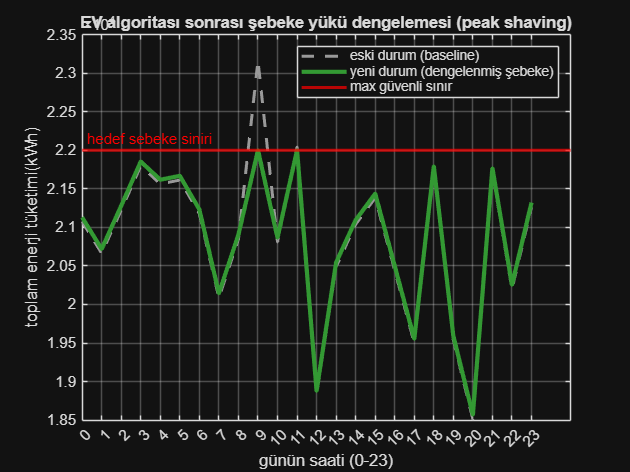

In [5]:
optimized_energy = baseline_data.sum_energy_dispensed_kwh;
asan_saatler = optimized_energy>sebeke_siniri;
toplam_fazla_enerji = sum(optimized_energy(asan_saatler) - sebeke_siniri);
optimized_energy(asan_saatler)= sebeke_siniri;


vadi_saatleri = optimized_energy < sebeke_siniri;
toplam_vadi_sayisi = sum(vadi_saatleri);


enerji_payi = toplam_fazla_enerji/toplam_vadi_sayisi;
optimized_energy(vadi_saatleri) = optimized_energy(vadi_saatleri) + enerji_payi;


figure;


plot(baseline_data.timeofday, baseline_data.sum_energy_dispensed_kwh, '--', 'LineWidth', 2, 'Color', [0.6 0.6 0.6]);
hold on;


plot(baseline_data.timeofday, optimized_energy, 'LineWidth', 2.8, 'Color', [0.2 0.6 0.2]);
yline(sebeke_siniri, '-r', 'hedef sebeke siniri', 'LineWidth', 2, 'LabelHorizontalAlignment', 'left');


grid on;
xlabel('günün saati (0-23)');
ylabel('toplam enerji tüketimi(kWh)');
title('EV algoritası sonrası şebeke yükü dengelemesi (peak shaving)');
legend('eski durum (baseline)', 'yeni durum (dengelenmiş şebeke)', 'max güvenli sınır');
xticks(0:23);


Peak noktaları grafiğin içerisinde dağıtmak kolay olsa da gerçek değerlerde bu durum, grafik üzerindeki kadar kolay gerçekleşebilir gibi görünmüyor.

**İdeal olan grafiği elde edebilmek için ne tür çalışmalar yürütülebilir?**

Şebekenin daha sakin olduğu saatlerde indirimler uygulamak ilk akla gelen yöntemlerden birisi gibi görünüyor. Ancak bu yüzeysel bir çözm olacktır ve beklenen sonucu vermeyebilir.

En uygun geliştirmelerden birisi Akıllı İstasyonlar yaratmak gibi görünüyor. Tüketicinin belirttiği 'şarj edilebilir' vakit boyunca otomasyon şebekenin en uygun ve en verimli saatinde ve süre boyunca aracı şarj edebilir.